In [2]:
!pip install -q tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras import Model
import numpy as np
import matplotlib.pyplot as plt

In [3]:

print("GPU disponível?", tf.config.list_physical_devices('GPU'))


GPU disponível? [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data() # matrizes coloridas
x_train, x_test = x_train / 255.0, x_test / 255.0 # normaliza cores
y_train, y_test = y_train.flatten(), y_test.flatten() # transforma em vetor
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3) (50000,) (10000,)


In [10]:
K = len(set(y_train))
print(K)

#buildando o modelo mas agora usando functional API

i = Input(shape=x_train[0].shape) # 60000 imagens na entrada

# "x" é a variavel em que sera feita a construção da rede, 32 filtros 3x3,
# com passo (stride) de 2 pixels, ou seja, com sobreposição, pra limiar de ativação vai ser usado ReLu
# e essa primeira camada de convolução "x" é aplicada sobre o tensor "i"
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
print("output primeira camada", x)

#igual a anterior mas com 64 fitros, é interessante observar que a sobreposição causada por um stride=2 em um filtro 3x3
# pode dispensar o uso de pooling já que ocorre a redução da dimensionalidade por 2
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
print("output segunda camada", x)

# igual a anterior mas com 128 kernels
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
print("output terceira camada", x)

#aplica-se um dropout
x = Flatten()(x) # vetoriza-se antes de entrar na ANN
print("output flatten", x)

x = Dropout(0.2)(x) # dropout de 20%
print("entrada ANN", x[1])
 # x é um vetor de 512 após o flattening e o dropout



x = Dense(1152, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)



10
output primeira camada <KerasTensor shape=(None, 15, 15, 32), dtype=float32, sparse=False, name=keras_tensor_35>
output segunda camada <KerasTensor shape=(None, 7, 7, 64), dtype=float32, sparse=False, name=keras_tensor_36>
output terceira camada <KerasTensor shape=(None, 3, 3, 128), dtype=float32, sparse=False, name=keras_tensor_37>
output flatten <KerasTensor shape=(None, 1152), dtype=float32, sparse=False, name=keras_tensor_38>
entrada ANN <KerasTensor shape=(1152,), dtype=float32, sparse=False, name=keras_tensor_40>


In [11]:
#compilando e fitting

r = model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [12]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.3677 - loss: 1.7182 - val_accuracy: 0.5395 - val_loss: 1.2816
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5686 - loss: 1.2099 - val_accuracy: 0.6189 - val_loss: 1.0755
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6387 - loss: 1.0182 - val_accuracy: 0.6570 - val_loss: 0.9668
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6887 - loss: 0.8797 - val_accuracy: 0.6797 - val_loss: 0.9080
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7305 - loss: 0.7605 - val_accuracy: 0.6885 - val_loss: 0.8999


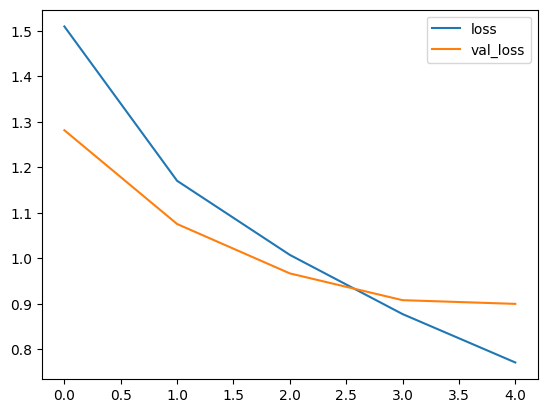

In [13]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

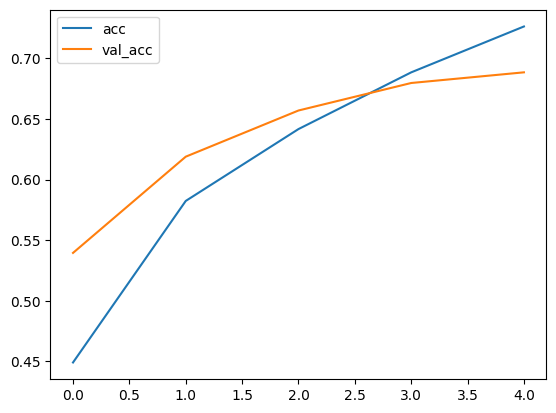

In [14]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
confusion matrix, without normalization
[[803  27  25   6   7   1  10   9  83  29]
 [ 22 867   4  12   1   1   5   0  26  62]
 [102  17 590  63  76  34  38  40  25  15]
 [ 47  24  62 537  66  96  60  52  26  30]
 [ 53   6  85  71 599  16  30 104  26  10]
 [ 27  12  72 266  41 445  27  77  26   7]
 [ 18  24  60  61  67  17 712  13  13  15]
 [ 34   4  32  38  43  29   6 780   8  26]
 [ 62  47  11   7   2   2   3   7 829  30]
 [ 47 147  12   7   3   4   6  17  34 723]]


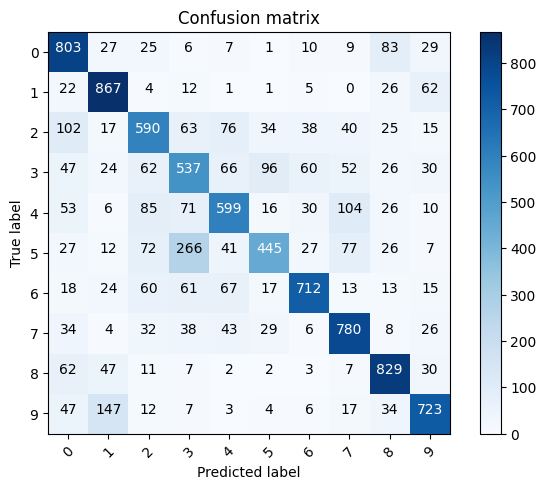

In [15]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
    else:
      print('confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))


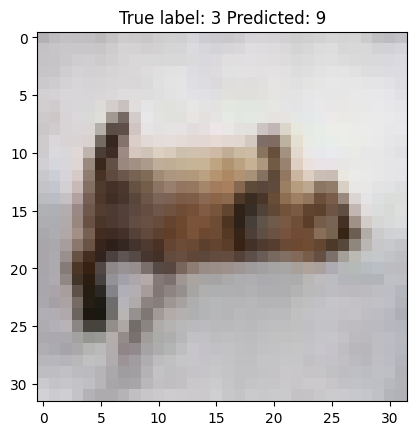

In [18]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (y_test[i], p_test[i]));